## Overview figures

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

# custom functions
import sc_toolbox as sct

Running Scanpy 1.8.2, on 2024-08-11 09:19.


In [2]:
## path variables
adata_dir = '/mnt/smb2/Niklas/GLPG_data_temp/240731_GLPG_annotated.h5ad'
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/'
out_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig1/'

In [3]:
## plotting variables
sc.settings.figdir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig1/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load anndata object
adata = sc.read(adata_dir)

In [5]:
## have a look at the adata object: 442k cells x 25194 genes
adata

AnnData object with n_obs × n_vars = 442439 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'GLPG_annotation_colors', 'cell_type_colors', 'condition_colors', 'hvg', 'louvain_1_colors', 'neighbors', 'pca', 'time_point_colors', 'treatment_colors', 'treatment_time_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'unsouped_counts'
    obsp: 'connectivities', 'distances'

### Correct some metadata labels

In [6]:
adata.obs['treatment'].cat.categories

Index(['none', 'vehicle', 'Nintedanib', 'GLPG1205', 'GLPG1690', 'Combo'], dtype='object')

In [7]:
## rename treatmentlabel
treatment_conversion = {'none' : 'PBS',
                        'vehicle' : 'Bleo',
                        'Nintedanib' : 'Bleo+Nintedanib',
                        'GLPG1205' : 'Bleo+GLPG1205',
                        'GLPG1690' : 'Bleo+GLPG1690',
                        'Combo' : 'Bleo+Combo'
}
adata.obs['treatment'] = [treatment_conversion[tt] for tt in adata.obs['treatment']]

In [13]:
adata.obs['treatment'] = adata.obs['treatment'].astype('category')
adata.obs['treatment'] = adata.obs['treatment'].cat.reorder_categories(['PBS',
                                                                         'Bleo',
                                                                         'Bleo+Nintedanib',
                                                                         'Bleo+GLPG1690',
                                                                         'Bleo+GLPG1205',
                                                                         'Bleo+Combo'])

### Summary Figures

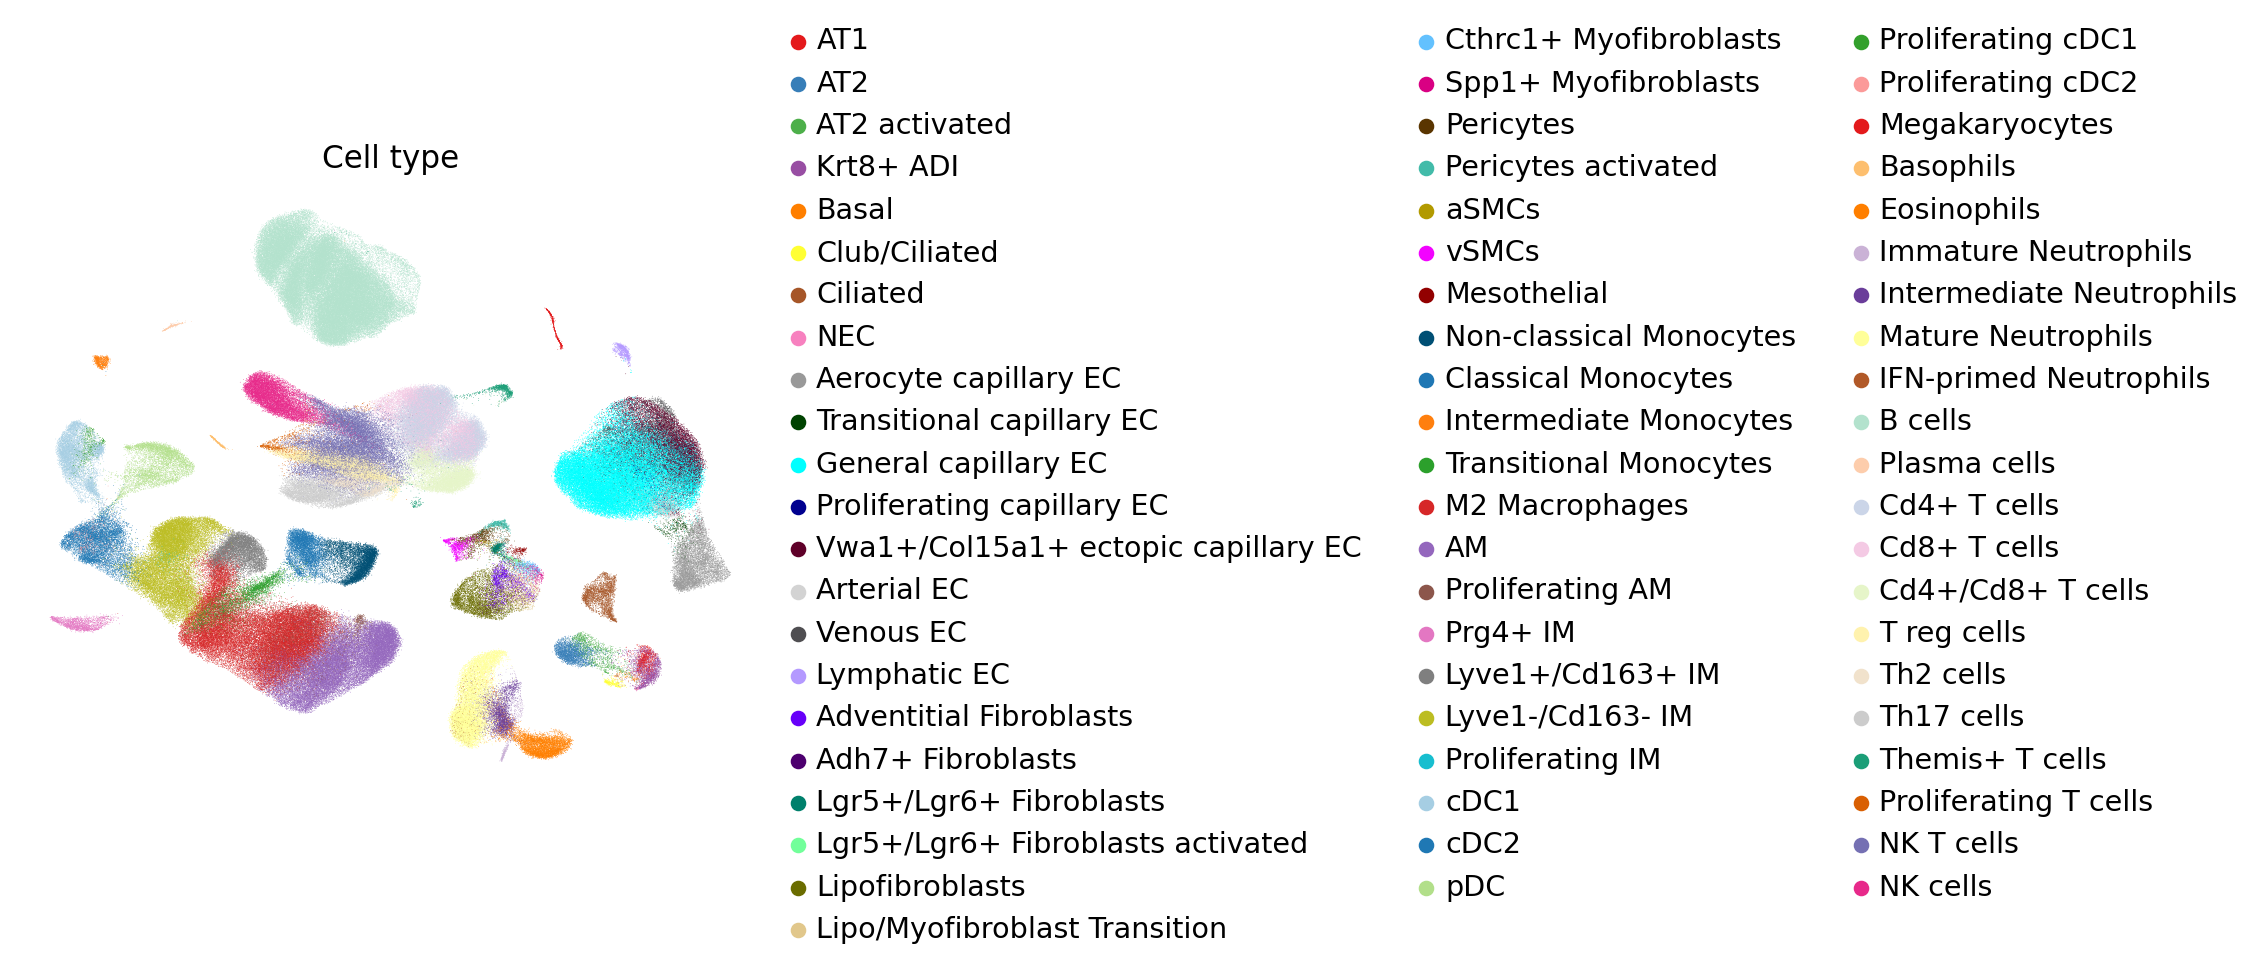

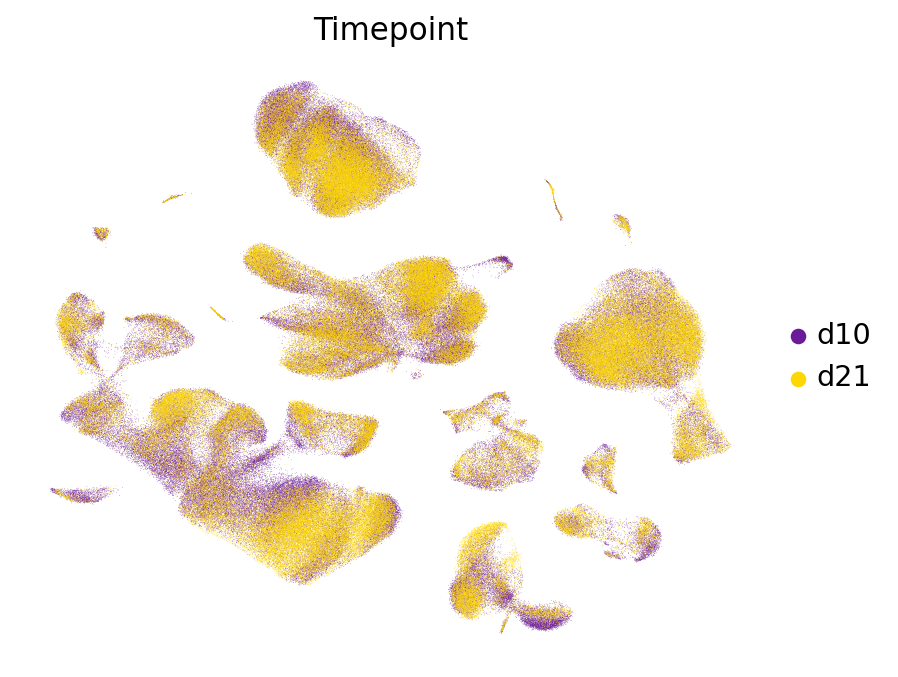

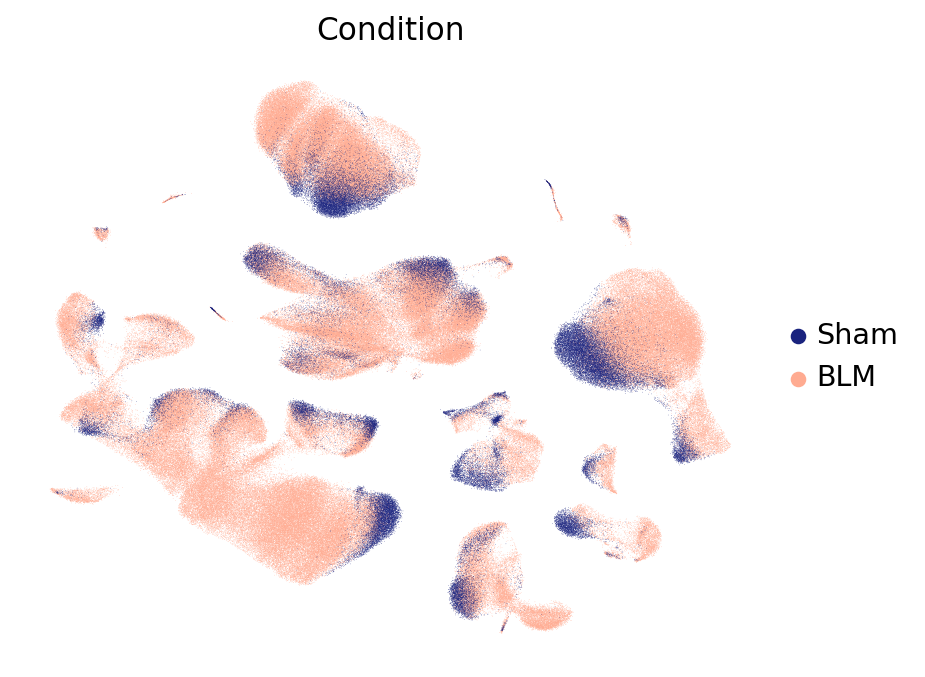

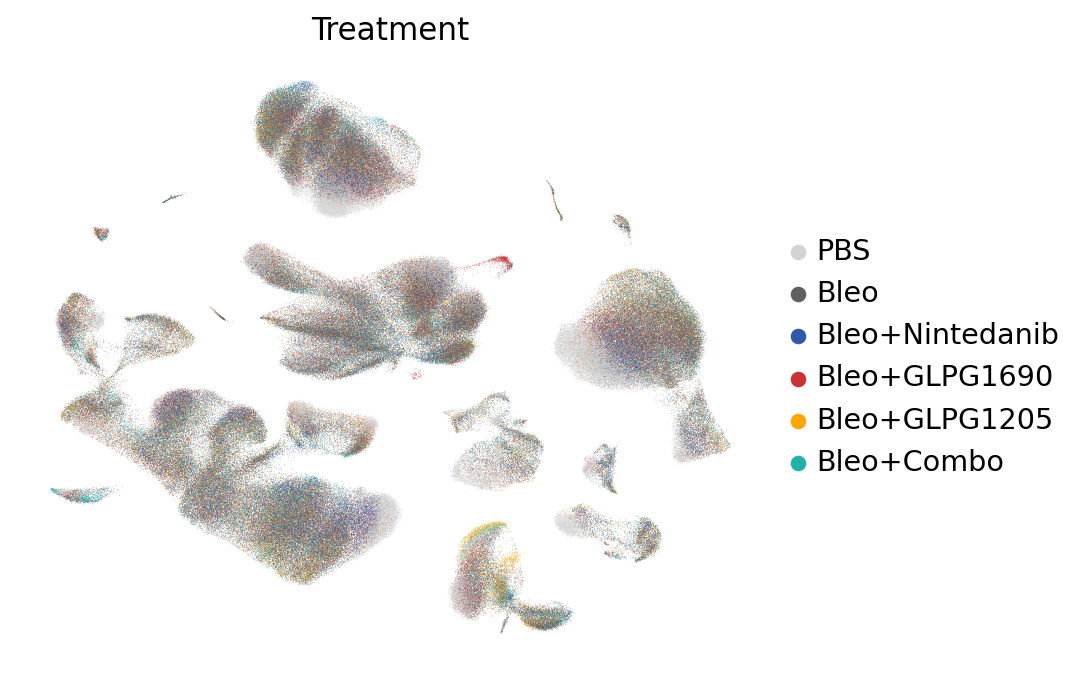

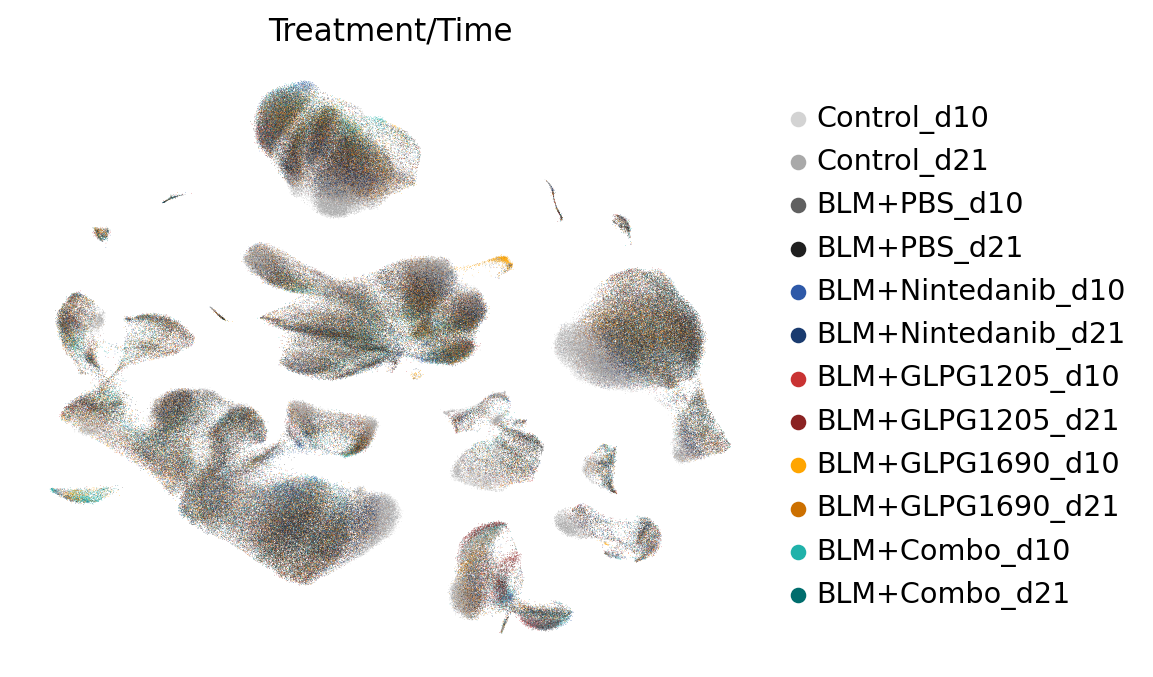

In [14]:
## save UMAP for presentation
sc.pl.umap(adata, color = ['cell_type'], title = 'Cell type', frameon = False, size = 0.4,
           save = '_celltype.pdf')
sc.pl.umap(adata, color = ['time_point'], title = 'Timepoint', frameon = False, 
           save = '_timepoint.pdf')
sc.pl.umap(adata, color = ['condition'], title = 'Condition', frameon = False,
           save = '_condition.pdf')
sc.pl.umap(adata, color = ['treatment'], title = 'Treatment', frameon = False,
           save = '_treatment.pdf')
sc.pl.umap(adata, color = ['treatment_time'], title = 'Treatment/Time', frameon = False, 
           save = '_treatment_time.pdf')

### Marker gene calculation and visualisation

In [33]:
sc.tl.rank_genes_groups(adata, groupby='cell_type', method='wilcoxon')

ranking genes


/home/niklas/miniconda3/envs/niche_fibrosis_env/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:394: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/home/niklas/miniconda3/envs/niche_fibrosis_env/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/home/niklas/miniconda3/envs/niche_fibrosis_env/lib/python3.8/site-packages/scanpy/to

    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:20:45)


In [34]:
## filter marker genes
sc.tl.filter_rank_genes_groups(adata, min_fold_change=2, min_in_group_fraction = 0.1, max_out_group_fraction = 0.25)

Filtering genes using: min_in_group_fraction: 0.1 min_fold_change: 2, max_out_group_fraction: 0.25


In [35]:
## matrix plot per cell type with top 5 genes per cell type
sc.pl.rank_genes_groups_matrixplot(adata, 
                                   n_genes = 5, 
                                   standard_scale = 'var', 
                                   groupby = 'cell_type',
                                   save= 'auto_markers.pdf')